Analyse et prediction de la consommation energetique

In [1]:
!pip install -q scikit-learn matplotlib seaborn pandas numpy joblib

import io
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42
print('Libraries ready')

Libraries ready


## 1. Chargement des donnees



In [2]:
uploaded = files.upload()

def read_csv_auto(name, raw):
    sample = raw[:3000].decode('utf-8', errors='ignore')
    sep = ';' if sample.count(';') > sample.count(',') else ','
    return pd.read_csv(io.BytesIO(raw), sep=sep, low_memory=False)

dataframes = {name: read_csv_auto(name, raw) for name, raw in uploaded.items()}
for name, frame in dataframes.items():
    print(f'{name}: {frame.shape[0]:,} rows x {frame.shape[1]} columns')
    print(frame.columns.tolist()[:20])

Saving power-laws-forecasting-energy-consumption-test-data.csv to power-laws-forecasting-energy-consumption-test-data.csv
power-laws-forecasting-energy-consumption-test-data.csv: 1,309,176 rows x 5 columns
['obs_id', 'SiteId', 'Timestamp', 'ForecastId', 'Value']


In [3]:
def find_consumption_table(dfs):
    for name, frame in dfs.items():
        cols = {c.lower(): c for c in frame.columns}
        if 'value' in cols and any(k in cols for k in ['timestamp', 'time', 'datetime', 'date']):
            return name, frame.copy()
    raise ValueError('No consumption table found. Expected a CSV with Value and Timestamp columns.')

consumption_name, df_raw = find_consumption_table(dataframes)
print('Consumption file:', consumption_name)
display(df_raw.head())

Consumption file: power-laws-forecasting-energy-consumption-test-data.csv


,obs_id,SiteId,Timestamp,ForecastId,Value
0,323604,235,2014-01-02T19:00:00+00:00,5004,157265.446409
1,2813181,235,2014-01-02T22:00:00+00:00,5004,155498.418922
2,4006999,235,2014-01-02T22:45:00+00:00,5004,155498.418922
3,106973,235,2014-01-03T00:30:00+00:00,5004,157265.446409
4,6793052,235,2014-01-13T14:15:00+00:00,5005,91885.429363


## 2. Exploration initiale (EDA)

In [4]:
print('Shape:', df_raw.shape)
print('
Info:')
df_raw.info()
print('
Describe:')
display(df_raw.describe(include='all').T)

missing = pd.DataFrame({
    'missing_count': df_raw.isna().sum(),
    'missing_pct': (df_raw.isna().mean() * 100).round(2)
}).sort_values('missing_count', ascending=False)
display(missing[missing.missing_count > 0])
print('Duplicates:', df_raw.duplicated().sum())

SyntaxError: unterminated string literal (detected at line 2) (410281988.py, line 2)

## 3. Nettoyage et feature engineering temporel

In [5]:
df = df_raw.copy()

# Colonnes importantes du dataset Kaggle
TARGET = 'Value'
TIME_COL = 'Timestamp'
SITE_COL = 'SiteId' if 'SiteId' in df.columns else None

if TARGET not in df.columns:
    raise ValueError(f'Missing target column: {TARGET}')
if TIME_COL not in df.columns:
    candidates = [c for c in df.columns if any(k in c.lower() for k in ['time', 'date', 'stamp'])]
    if not candidates:
        raise ValueError('No timestamp column found. This SG02 dataset should contain Timestamp.')
    TIME_COL = candidates[0]

MAX_ROWS = 50_000
if len(df) > MAX_ROWS:
    df = df.sort_values(TIME_COL).iloc[:MAX_ROWS].copy()

before = len(df)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors='coerce')
df[TARGET] = pd.to_numeric(df[TARGET], errors='coerce')
df = df.dropna(subset=[TIME_COL, TARGET])
df = df.drop_duplicates().sort_values(TIME_COL).reset_index(drop=True)

# Filtrage robuste des valeurs extr?mes: 1er-99e percentiles
q01, q99 = df[TARGET].quantile([0.01, 0.99])
df = df[(df[TARGET] >= q01) & (df[TARGET] <= q99)].reset_index(drop=True)

# Features temporelles
df['hour'] = df[TIME_COL].dt.hour
df['day_of_week'] = df[TIME_COL].dt.dayofweek
df['month'] = df[TIME_COL].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['season'] = df['month'].map({12:0,1:0,2:0,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3})

print(f'Removed {before - len(df):,} rows during cleaning')
print(f'Clean rows: {len(df):,}')
assert len(df) >= 10_000, 'Dataset must contain at least 10,000 rows after cleaning'
display(df.head())

Removed 1,461 rows during cleaning
Clean rows: 48,539


,obs_id,SiteId,Timestamp,ForecastId,Value,hour,day_of_week,month,is_weekend,season
0,1255139,297,2009-08-02 10:45:00+00:00,6603,86278.056494,10,6,8,1,2
1,4354443,297,2009-08-02 11:45:00+00:00,6603,86278.056494,11,6,8,1,2
2,5251714,297,2009-08-02 12:45:00+00:00,6603,86278.056494,12,6,8,1,2
3,259576,297,2009-08-02 13:45:00+00:00,6603,86278.056494,13,6,8,1,2
4,5710049,297,2009-08-02 14:45:00+00:00,6603,86278.056494,14,6,8,1,2


## 4. Fusion optionnelle avec metadata et meteo



In [6]:
def find_table_with_column(dfs, required_cols, exclude_name=None):
    required = {c.lower() for c in required_cols}
    for name, frame in dfs.items():
        if name == exclude_name:
            continue
        cols = {c.lower() for c in frame.columns}
        if required.issubset(cols):
            return name, frame.copy()
    return None, None

# Metadata: table with SiteId but no Timestamp usually
meta_name, meta = None, None
if SITE_COL:
    for name, frame in dataframes.items():
        low = [c.lower() for c in frame.columns]
        if name != consumption_name and 'siteid' in low and not any(c in low for c in ['timestamp', 'time', 'datetime']):
            meta_name, meta = name, frame.copy()
            break

if meta is not None:
    print('Merging metadata:', meta_name)
    df = df.merge(meta.drop_duplicates(subset=[SITE_COL]), on=SITE_COL, how='left')
else:
    print('No metadata file detected')

# Weather: table with Timestamp, optionally SiteId
weather_name, weather = None, None
for name, frame in dataframes.items():
    low = [c.lower() for c in frame.columns]
    if name != consumption_name and any(c in low for c in ['timestamp', 'time', 'datetime', 'date']):
        weather_name, weather = name, frame.copy()
        break

if weather is not None:
    print('Merging weather:', weather_name)
    w_time = next(c for c in weather.columns if any(k in c.lower() for k in ['timestamp', 'time', 'datetime', 'date']))
    weather[w_time] = pd.to_datetime(weather[w_time], errors='coerce')
    weather = weather.dropna(subset=[w_time]).sort_values(w_time)
    left = df.sort_values(TIME_COL)
    if SITE_COL and SITE_COL in weather.columns:
        df = pd.merge_asof(left, weather.sort_values(w_time), left_on=TIME_COL, right_on=w_time, by=SITE_COL, direction='nearest')
    else:
        df = pd.merge_asof(left, weather.sort_values(w_time), left_on=TIME_COL, right_on=w_time, direction='nearest')
else:
    print('No weather file detected. The model will use temporal + available numeric metadata features.')

print('Final shape after optional merges:', df.shape)
print(df.columns.tolist())

No metadata file detected
No weather file detected. The model will use temporal + available numeric metadata features.
Final shape after optional merges: (48539, 10)
['obs_id', 'SiteId', 'Timestamp', 'ForecastId', 'Value', 'hour', 'day_of_week', 'month', 'is_weekend', 'season']


## 5. Visualisation avancne

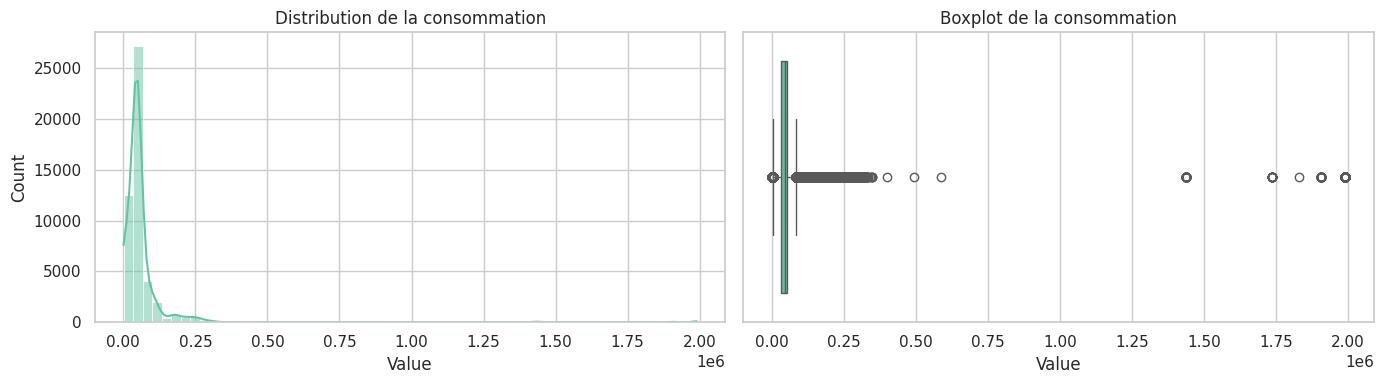

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df[TARGET], bins=60, kde=True, ax=axes[0])
axes[0].set_title('Distribution de la consommation')
sns.boxplot(x=df[TARGET], ax=axes[1])
axes[1].set_title('Boxplot de la consommation')
plt.tight_layout(); plt.show()

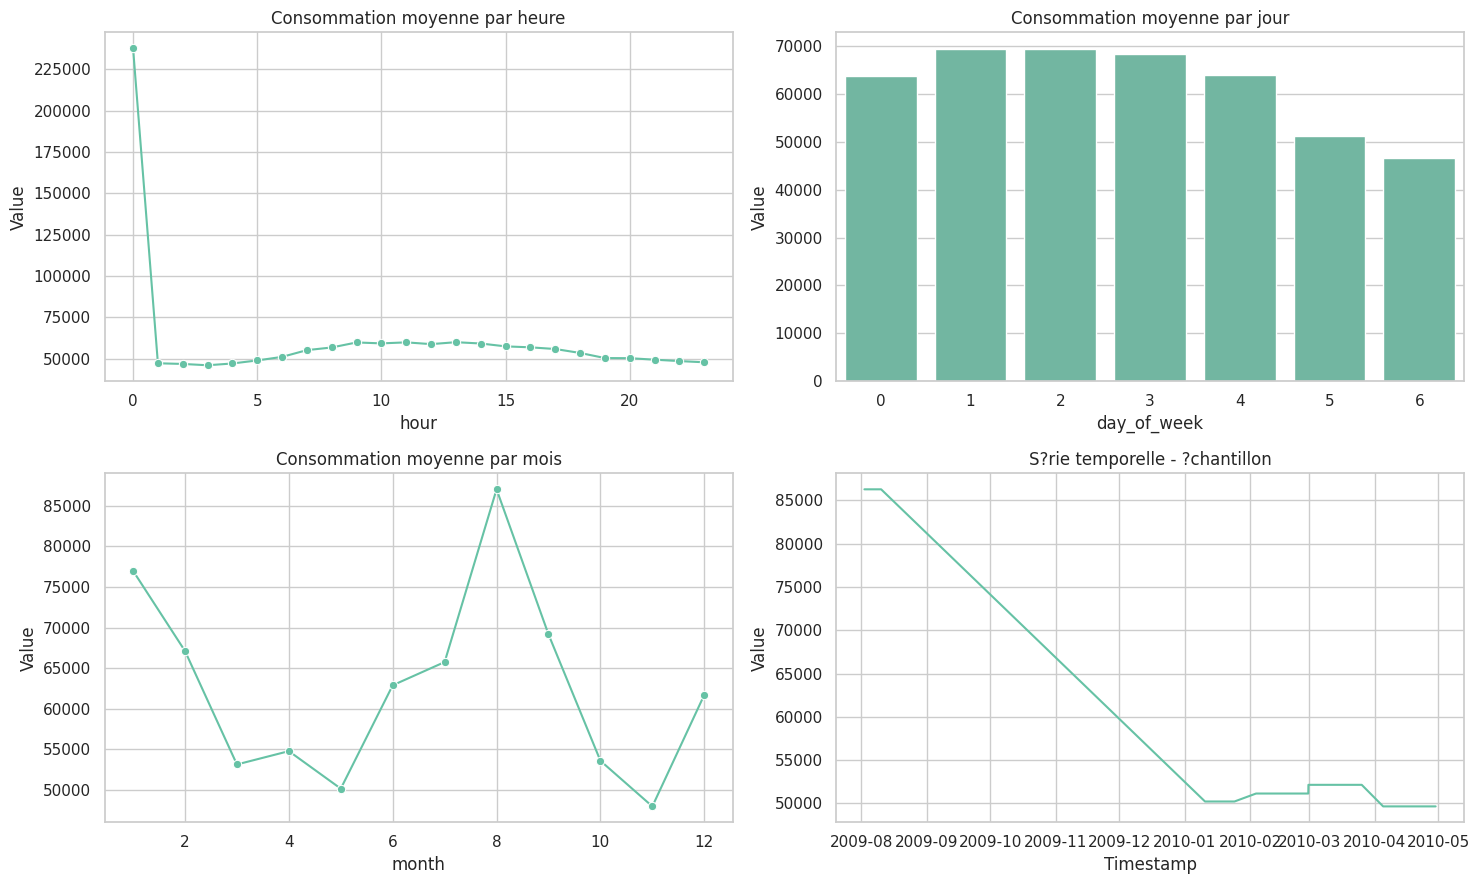

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
sns.lineplot(data=df.groupby('hour')[TARGET].mean().reset_index(), x='hour', y=TARGET, marker='o', ax=axes[0,0])
axes[0,0].set_title('Consommation moyenne par heure')
sns.barplot(data=df.groupby('day_of_week')[TARGET].mean().reset_index(), x='day_of_week', y=TARGET, ax=axes[0,1])
axes[0,1].set_title('Consommation moyenne par jour')
sns.lineplot(data=df.groupby('month')[TARGET].mean().reset_index(), x='month', y=TARGET, marker='o', ax=axes[1,0])
axes[1,0].set_title('Consommation moyenne par mois')
sample_ts = df[[TIME_COL, TARGET]].iloc[:2000]
sns.lineplot(data=sample_ts, x=TIME_COL, y=TARGET, ax=axes[1,1])
axes[1,1].set_title('S?rie temporelle - ?chantillon')
plt.tight_layout(); plt.show()

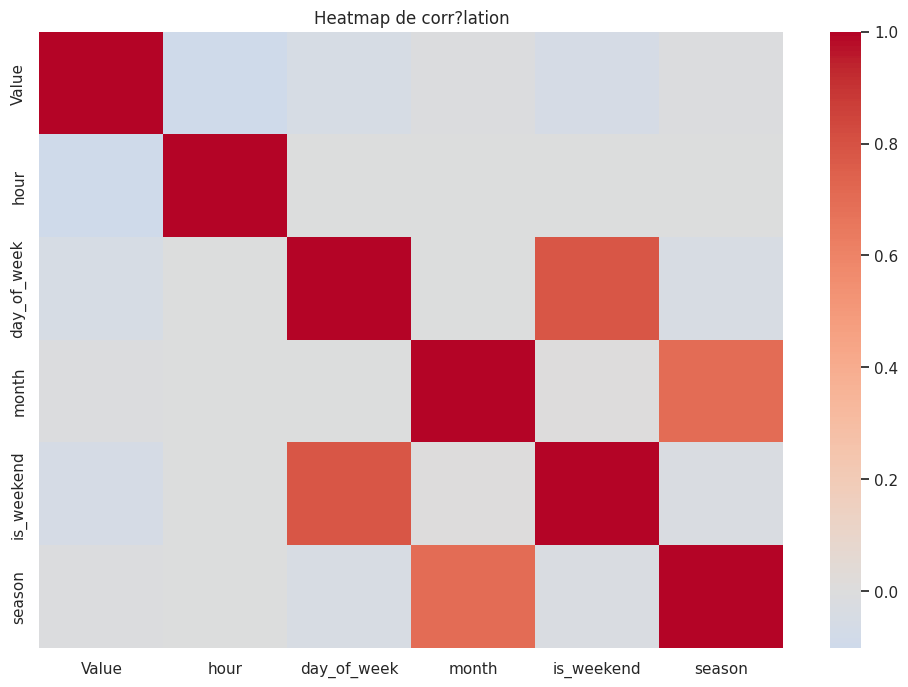

Top correlations with Value:


,Value
hour,-0.100727
is_weekend,-0.060786
day_of_week,-0.049625
season,-0.010012
month,-0.009166


In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
ignore = [c for c in numeric_cols if 'id' in c.lower() or c.lower().endswith('id')]
feature_candidates = [c for c in numeric_cols if c not in ignore]

corr = df[feature_candidates].corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Heatmap de corr?lation')
plt.show()

target_corr = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
print('Top correlations with Value:')
display(target_corr.head(12))

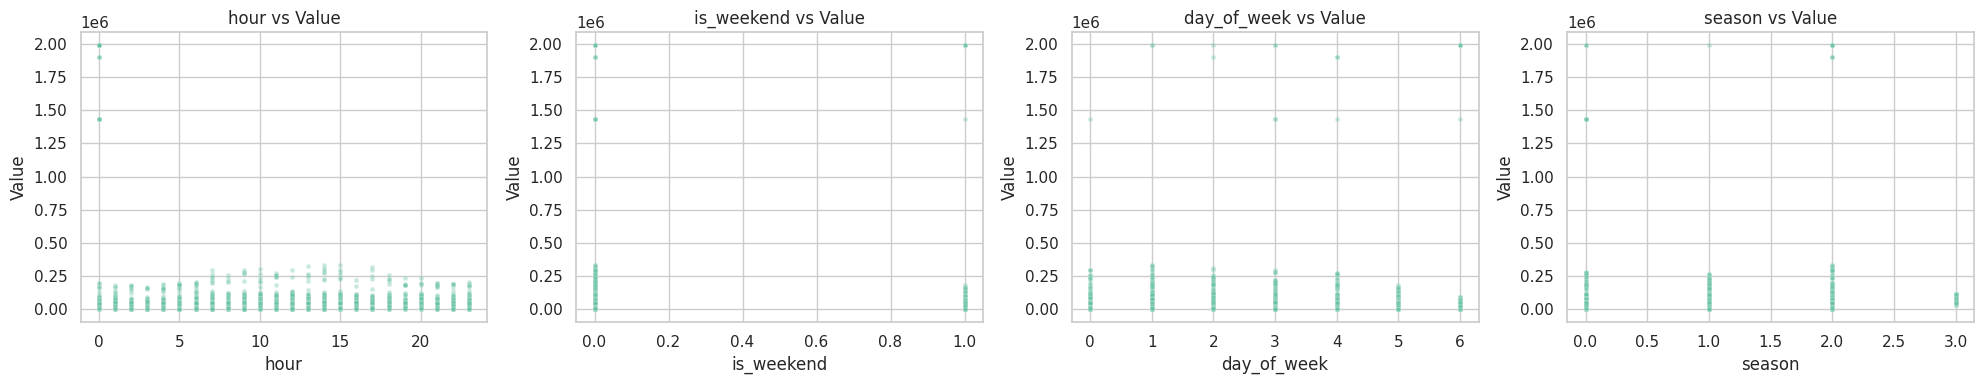

In [10]:
top_feats = target_corr.head(4).index.tolist()
sample = df.sample(min(3000, len(df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, len(top_feats), figsize=(5 * len(top_feats), 4))
if len(top_feats) == 1:
    axes = [axes]
for ax, feat in zip(axes, top_feats):
    sns.scatterplot(data=sample, x=feat, y=TARGET, s=12, alpha=0.35, ax=ax)
    ax.set_title(f'{feat} vs Value')
plt.tight_layout(); plt.show()

## 6. Preprocessing et Machine Learning




In [11]:
base_features = ['hour', 'day_of_week', 'month', 'is_weekend', 'season']
extra_features = [
    c for c in feature_candidates
    if c not in base_features + [TARGET] and df[c].nunique(dropna=True) > 2
]
features = base_features + extra_features[:10]

model_df = df[features + [TARGET]].dropna().copy()
X = model_df[features]
y = model_df[TARGET]

split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print('Features used:')
for f in features:
    print('-', f)
print(f'Train rows: {len(X_train):,} | Test rows: {len(X_test):,}')

Features used:
- hour
- day_of_week
- month
- is_weekend
- season
Train rows: 38,831 | Test rows: 9,708


In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, random_state=RANDOM_STATE),
}

results = []
fitted = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    fitted[name] = {'model': model, 'preds': preds, 'mae': mae, 'rmse': rmse, 'r2': r2}

metrics = pd.DataFrame(results).sort_values('RMSE')
display(metrics)
best_name = metrics.iloc[0]['model']
best = fitted[best_name]
print('Best model:', best_name)

,model,MAE,RMSE,R2
1,Ridge Regression,49347.842496,66913.624165,-0.090866
0,Linear Regression,49347.943825,66913.743459,-0.090869
3,Gradient Boosting,64212.303731,127024.299993,-2.931115
2,Random Forest,66572.900449,134383.919606,-3.399838


Best model: Ridge Regression


## 7. Evaluation du meilleur modele

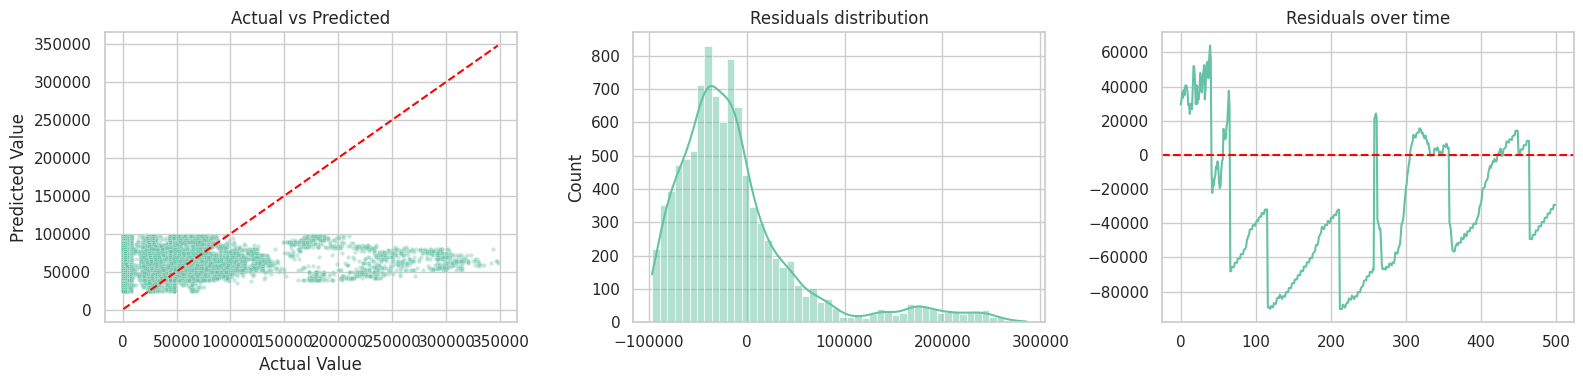

MAE  = 49347.8425
RMSE = 66913.6242
R2   = -0.0909


In [13]:
preds = best['preds']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(x=y_test, y=preds, s=10, alpha=0.35, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Value'); axes[0].set_ylabel('Predicted Value')

residuals = y_test.values - preds
sns.histplot(residuals, bins=50, kde=True, ax=axes[1])
axes[1].set_title('Residuals distribution')

axes[2].plot(residuals[:500])
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuals over time')
plt.tight_layout(); plt.show()

print(f"MAE  = {best['mae']:.4f}")
print(f"RMSE = {best['rmse']:.4f}")
print(f"R2   = {best['r2']:.4f}")

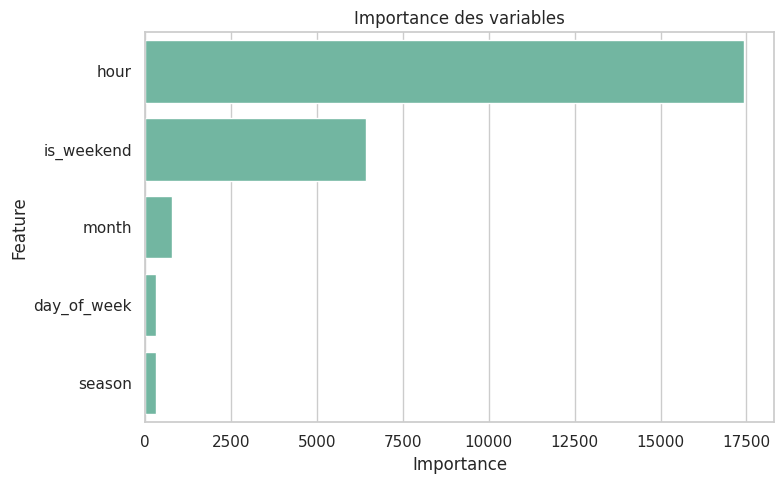

In [14]:
model_obj = best['model']
if hasattr(model_obj, 'feature_importances_'):
    imp = pd.Series(model_obj.feature_importances_, index=features).sort_values(ascending=False)
else:
    imp = pd.Series(np.abs(getattr(model_obj, 'coef_', np.zeros(len(features)))), index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index)
plt.title('Importance des variables')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout(); plt.show()

## 8. Export pour l'application



In [15]:
artifacts = {
    'model': model_obj,
    'scaler': scaler,
    'features': features,
    'target': TARGET,
    'mae': best['mae'],
    'rmse': best['rmse'],
    'r2': best['r2'],
}
with open('energy_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
files.download('energy_model.pkl')
print('energy_model.pkl exported')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

energy_model.pkl exported
